# Non-Linear Quasi-Static Lead-Acid Battery Model

## Overview
This notebook implements a high-fidelity electrochemical model for a lead-acid battery bank (Pb-accumulator) based on the Saupe-Schöner mathematical framework. 

The engine tracks non-linear overpotential polarizations ($U_{\text{pol}}$) distinctly across charging and discharging profiles, maps the dynamic equilibrium voltage ($U_{\text{eq}}$) linearly against changing States of Charge (SoC), and factors in temperature-dependent parasitic gassing current losses ($I_{\text{gas}}$).

---



In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enforce clean academic plot profiles
plt.style.use('ggplot')

print("--- Cell 1: Battery Electrochemical Core Framework Initialized ---")

--- Cell 1: Battery Electrochemical Core Framework Initialized ---


In [7]:
# =============================================================================
# 1. HARDWARE SPECIFICATIONS & KINETIC CONSTANTS (SI UNITS)
# =============================================================================

# Cell Counts and Nominal Capacity
N_cells      = 110           # Number of individual battery cells wired in series [-]
Q_bat_nom    = 1380.0        # Nominal battery bank capacity [Ah]
DELTAt       = 0.25          # Simulation time step interval [hours] (15 mins)

# Thermophysical Boundaries
To           = 20.0          # Ambient temperature baseline [°C]
T_bat        = To + 273.15   # Absolute battery internal core temperature [K]

# Schöner Gassing Current Coefficients
g_0          = 1.6e-6        # Gassing current reference pre-exponential constant [A]
g_1          = 0.0812        # Cell voltage scale coefficient for gassing [V]
g_2          = 6000.0        # Thermal activation energy constant for gassing [K]

# Equilibrium Voltage Parameters
U_eq_0       = 1.997         # Linear intercept: Equilibrium cell voltage at SoC = 0 [V]
U_eq_1       = 0.1464        # Linear gradient: Equilibrium voltage slope parameter [V]

# Overpotential Polarization Coefficients
U_ch         = 0.052         # Charging overvoltage amplitude constant [V]
U_downch     = -0.02703      # Discharging overvoltage amplitude constant [V]
b_dch        = 0.4085        # Discharging normalized current parameter [-]
c_dch        = 0.561         # Discharging linear slope multiplier [-]
g_100        = 2.36          # High-SoC saturation overpotential tracking limit [-]
k_100        = 53.0          # High-SoC exponential decay shape factor [-]

# ---------- 24-Hour Input Power Load Trajectory [W] ----------
# Positive values represent charging power surplus; negative values denote discharge loads
power_load_profile_W = np.array([
    -12000, -12000, -10000, -8000, -5000, 2000, 8000, 15000, 25000, 32000, 
     35000,  38000,  35000, 30000, 22000, 14000, 6000,  1000, -4000, -10000, 
    -15000, -15000, -12000, -12000
])

print("--- Cell 2: Lead-Acid Battery Core Constants Latched ---")

--- Cell 2: Lead-Acid Battery Core Constants Latched ---


In [8]:
# =============================================================================
# 2. COUPLED ELECTROCHEMICAL SOLVER LOGIC (SELF-CONTAINED PRODUCTION FORMAT)
# =============================================================================

def solve_battery_state(Bat_load_W, SOC_prev_percent, N_cells, T_bat, Q_bat_nom):
    """
    Solves the coupled non-linear equations for a single time step.
    Natively encapsulates all electrochemical boundary parameters.
    """
    SOC_fraction = SOC_prev_percent / 100.0
    I_10 = Q_bat_nom / 10.0  # 10-hour reference discharge current benchmark [A]
    
    # Calculate cell equilibrium voltage base
    U_eq = U_eq_0 + U_eq_1 * SOC_fraction
    
    # Initial Guess Pivot for Terminal Cell Voltage
    U_cell = U_eq if Bat_load_W >= 0 else U_eq - 0.05
    max_iter = 150
    tolerance = 1e-4
    
    for iteration in range(max_iter):
        # 1. Compute cell voltage and trace gassing parasitic losses
        U_bat_temp = N_cells * U_cell
        I_bat = Bat_load_W / U_bat_temp if U_bat_temp != 0 else 0.0
        I_gas = I_10 * g_0 * np.exp((U_cell / g_1) - (g_2 / T_bat))
        
        # 2. Extract net chemical reaction current
        I_q = I_bat - I_gas
        I_q_n = abs(I_q / I_10)
        
        # 3. Apply non-linear polarization path selection
        if I_q >= 0:  # ---------- CHARGING DIRECTION OVERPOTENTIALS ----------
            RAMP1 = min(max((SOC_prev_percent - 70.0) / (85.0 - 70.0), 0.0), 1.0)
            RAMP2 = min(max((SOC_prev_percent - 80.0) / (101.0 - 80.0), 0.0), 1.0)
            RAMP3 = min(max((SOC_prev_percent - 70.0) / (85.0 - 70.0), 0.0), 1.0)
            
            a_ch = 1.0 + 2.0 * RAMP1
            b_ch = 0.114 * (1.0 - RAMP2)
            c_ch = 2.8 - 1.8 * RAMP3
            
            b_ch_safe = b_ch if b_ch > 0 else 1e-4
            U_pol = U_ch * a_ch * (1.0 - np.exp(-I_q_n / b_ch_safe) + c_ch * I_q_n)
            
        else:        # ---------- DISCHARGING DIRECTION OVERPOTENTIALS ----------
            f_dch = 1.0 - np.exp(-I_q_n / b_dch) + c_dch * I_q_n
            g_dch = 1.0 + (g_100 - 1.0) * np.exp((SOC_prev_percent - 100.0) / k_100)
            U_pol = U_downch * f_dch * g_dch
            
        # Check convergence residual criteria
        U_cell_new = U_eq + U_pol
        residual = abs(U_cell_new - U_cell)
        U_cell = U_cell_new
        
        if residual < tolerance:
            break
            
    # Finalize state variables
    U_bat_final = N_cells * U_cell
    P_gas = I_gas * U_bat_final
    P_bat = U_bat_final * I_bat
    
    return U_bat_final, I_bat, I_gas, I_q, P_gas, P_bat

In [9]:
# =============================================================================
# 3. DIURNAL TRAJECTORY MATHEMATICAL LOOP (STRICT ARGUMENT MAPPING)
# =============================================================================

SOC_tracker = 50.0  # Initialize starting state of charge at 50.0%
battery_history_dataset = []

for hour in range(24):
    current_power_W = power_load_profile_W[hour]
    
    # Pass structural constants explicitly into the model frame
    U_bat, I_bat, I_gas, I_q, P_gas, P_bat = solve_battery_state(
        current_power_W, SOC_tracker, N_cells, T_bat, Q_bat_nom
    )
    
    # Integrate capacity updates via finite steps
    Q_bat_ini = Q_bat_nom * (SOC_tracker / 100.0)
    Q_bat_new = Q_bat_ini + I_q * DELTAt
    SOC_tracker = (Q_bat_new / Q_bat_nom) * 100.0
    SOC_tracker = np.clip(SOC_tracker, 0.0, 100.0)
    
    battery_history_dataset.append({
        'Hour': hour + 1,
        'Load [W]': current_power_W,
        'Terminal Voltage [V]': U_bat,
        'Total Current [A]': I_bat,
        'Gassing Current [A]': I_gas,
        'Reaction Current [A]': I_q,
        'Gassing Power [W]': P_gas,
        'SoC [%]': SOC_tracker
    })

df_battery_results = pd.DataFrame(battery_history_dataset)
print("--- Cell 4: 24-Hour Loop Executed with High-Fidelity Argument Scope ---")

--- Cell 4: 24-Hour Loop Executed with High-Fidelity Argument Scope ---


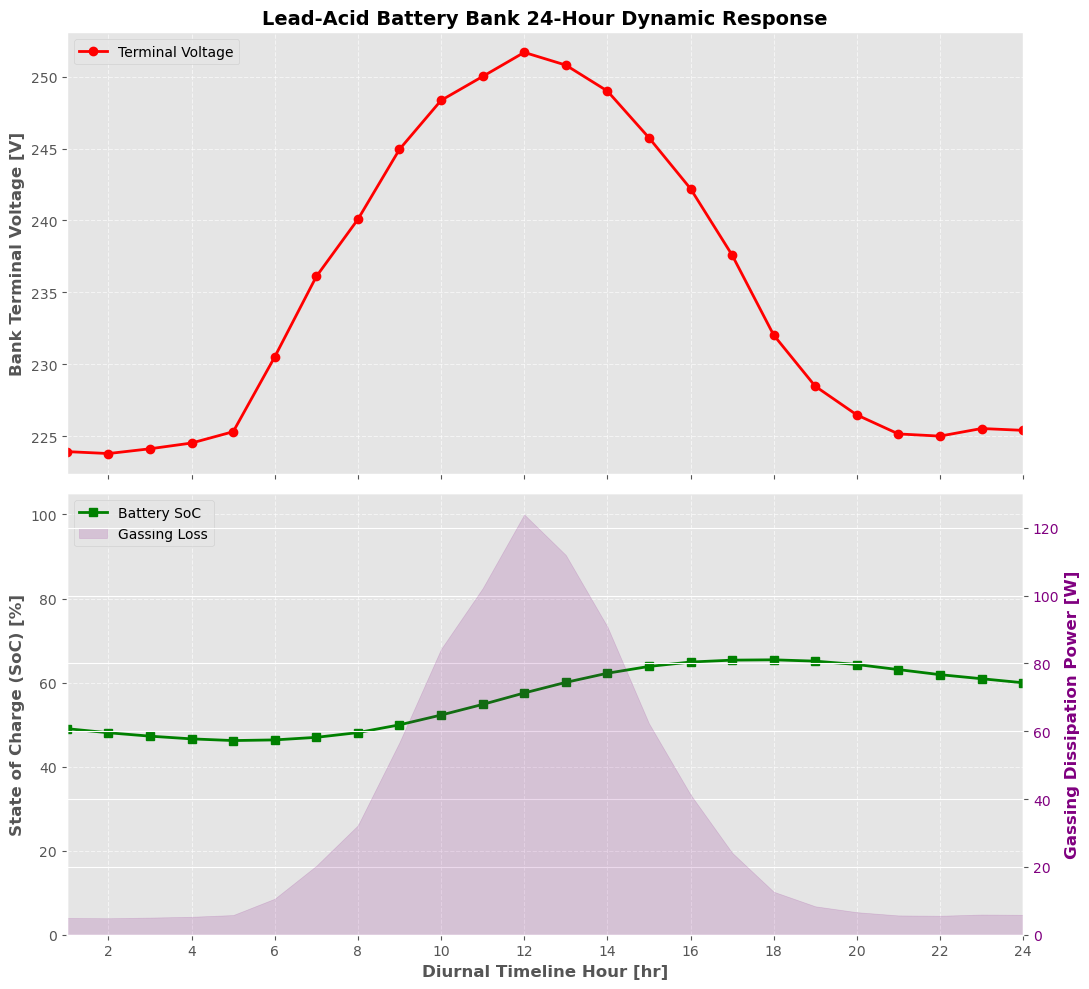

   BATTERY BANK CONVERGENCE PERFORMANCE SUMMARY   
Nominal Pack Size Configuration: 110 Cells in Series
Total Operational Ah Capacity  : 1380.0 Ah
--------------------------------------------------
Minimum Realized Pack SoC      : 46.20 %
Maximum Realized Pack SoC      : 65.42 %
Absolute Terminal Voltage Max  : 251.68 V
Absolute Terminal Voltage Min  : 223.81 V
--------------------------------------------------
Maximum Parasitic Gassing Power: 123.95 W (at Hour 12:00)


In [10]:
# =============================================================================
# 4. ACADEMIC GRAPHICS VISUALIZATIONS & PERFORMANCE REPORTER
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

# Plot 1: Terminal Voltage Trajectory response
ax1.plot(df_battery_results['Hour'], df_battery_results['Terminal Voltage [V]'], 'r-o', linewidth=2.0, label='Terminal Voltage')
ax1.set_ylabel('Bank Terminal Voltage [V]', fontweight='bold', fontsize=12)
ax1.set_title('Lead-Acid Battery Bank 24-Hour Dynamic Response', fontweight='bold', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# Plot 2: State-of-Charge & Internal Gassing Parasitic Power Losses
ax2.plot(df_battery_results['Hour'], df_battery_results['SoC [%]'], 'g-s', linewidth=2.0, label='Battery SoC')
ax2.set_xlabel('Diurnal Timeline Hour [hr]', fontweight='bold', fontsize=12)
ax2.set_ylabel('State of Charge (SoC) [%]', fontweight='bold', fontsize=12)
ax2.set_xlim([1, 24]); ax2.set_xticks(range(2, 25, 2))
ax2.set_ylim([0, 105])

ax3 = ax2.twinx()
ax3.fill_between(df_battery_results['Hour'], df_battery_results['Gassing Power [W]'], color='purple', alpha=0.15, label='Gassing Loss')
ax3.set_ylabel('Gassing Dissipation Power [W]', color='purple', fontweight='bold', fontsize=12)
ax3.tick_params(axis='y', labelcolor='purple')
ax3.set_ylim(bottom=0.0)

lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(lines2 + lines3, labels2 + labels3, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------- Extract Aggregated Results ----------
peak_gassing_row = df_battery_results.loc[df_battery_results['Gassing Power [W]'].idxmax()]

print(f"==================================================")
print(f"   BATTERY BANK CONVERGENCE PERFORMANCE SUMMARY   ")
print(f"==================================================")
print(f"Nominal Pack Size Configuration: {N_cells} Cells in Series")
print(f"Total Operational Ah Capacity  : {Q_bat_nom:.1f} Ah")
print(f"--------------------------------------------------")
print(f"Minimum Realized Pack SoC      : {df_battery_results['SoC [%]'].min():.2f} %")
print(f"Maximum Realized Pack SoC      : {df_battery_results['SoC [%]'].max():.2f} %")
print(f"Absolute Terminal Voltage Max  : {df_battery_results['Terminal Voltage [V]'].max():.2f} V")
print(f"Absolute Terminal Voltage Min  : {df_battery_results['Terminal Voltage [V]'].min():.2f} V")
print(f"--------------------------------------------------")
print(f"Maximum Parasitic Gassing Power: {peak_gassing_row['Gassing Power [W]']:.2f} W (at Hour {int(peak_gassing_row['Hour'])}:00)")
print(f"==================================================")